<a href="https://colab.research.google.com/github/seankim8724/AIFFEL_quest_eng/blob/main/NLP/NLP01/NLP01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 한영 Seq2Seq 번역 프로젝트 (Google Colab 전용)
이 노트북은 한국어-영어 병렬 데이터를 사용하여 **Attention 기반 Seq2Seq 번역 모델**을 만들고 학습하는 과정을 단계별로 설명합니다.

## 🚨 [필수] GPU 설정 방법 🚨
현재 노트북은 모델 훈련을 빠르게 하기 위해 **GPU**가 반드시 필요합니다.
1. 상단 메뉴에서 **런타임 (Runtime)** 을 클릭합니다.
2. **런타임 유형 변경 (Change runtime type)** 을 선택합니다.
3. 하드웨어 가속기(Hardware accelerator)를 **T4 GPU** 로 변경하고 저장합니다.
4. 다시 상단 메뉴에서 **런타임 -> 런타임 다시 시작 (Restart runtime)** 을 클릭합니다.


## Step 0. 필수 라이브러리 및 환경 설정
Google Colab 환경에 맞춰 한글 폰트(나눔고딕)와 형태소 분석기(MeCab)를 설치합니다.


In [ ]:
import sys
import os
import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 패키지 및 폰트 설치 (Colab 전용)
if 'google.colab' in sys.modules:
    print("Google Colab 환경입니다. 필수 패키지를 설치합니다...")
    os.system('sudo apt-get update')
    os.system('sudo apt-get install -y fonts-nanum')
    os.system('pip install sentencepiece tqdm pandas scikit-learn python-mecab-ko python-mecab-ko-dic')
    print("설치가 완료되었습니다.")

    # Colab에서 한글 폰트 설정
    fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
    try:
        fm.fontManager.addfont(fontpath)
    except Exception as e:
        print(f"폰트 추가 실패: {e}")
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False
else:
    print("이 노트북은 Google Colab에 최적화되어 있습니다.")


Google Colab 환경입니다. 필수 패키지를 설치합니다...
설치가 완료되었습니다.


## 디바이스(Device) 및 경로 설정
GPU가 정상적으로 활성화되었는지 확인합니다.


In [ ]:
import re
import urllib.request
import tarfile
import sentencepiece as spm
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import random

# ★ 디바이스 설정 (CUDA 강제 확인)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("✅ 디바이스: GPU (CUDA)가 정상적으로 설정되었습니다!")
else:
    device = torch.device("cpu")
    print("❌ 디바이스: CPU")
    print("경고: GPU가 켜져있지 않아 훈련 속도가 매우 느립니다! 상단 메뉴의 [런타임] -> [런타임 유형 변경]에서 T4 GPU를 선택해주세요.")

# 데이터 저장 경로 설정 (Colab 전용 경로)
dataset_dir = "/content/datasets"
os.makedirs(dataset_dir, exist_ok=True)
print(f"데이터 경로: {dataset_dir}")


✅ 디바이스: GPU (CUDA)가 정상적으로 설정되었습니다!
데이터 경로: /content/datasets


## MeCab 작동 테스트
MeCab이 제대로 설치되었는지 확인합니다.


In [ ]:
from mecab import MeCab
mecab = MeCab()

sample = "아이펠에서 자연어 처리를 즐겁게 배우고 있습니다."
print(f"원본: {sample}")
print(f"형태소: {mecab.morphs(sample)}")
print("✅ MeCab 정상 작동!")


원본: 아이펠에서 자연어 처리를 즐겁게 배우고 있습니다.
형태소: ['아이펠', '에서', '자연어', '처리', '를', '즐겁', '게', '배우', '고', '있', '습니다', '.']
✅ MeCab 정상 작동!


---
## Step 1. 데이터 다운로드


In [ ]:
tar_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")

if not os.path.exists(tar_path):
    print("한영 병렬 데이터 다운로드 중...")
    url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"
    urllib.request.urlretrieve(url, tar_path)
    print("다운로드 완료!")

data_folder = os.path.join(dataset_dir, "korean-english-park")
if not os.path.exists(data_folder):
    os.makedirs(data_folder, exist_ok=True)
    print("압축 해제 중...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=data_folder)
    print(f"압축 해제 완료: {data_folder}")

# 데이터 로드
kor_path = os.path.join(data_folder, "korean-english-park.train.ko")
eng_path = os.path.join(data_folder, "korean-english-park.train.en")

with open(kor_path, "r", encoding="utf-8") as f:
    raw_kor = f.read().splitlines()
with open(eng_path, "r", encoding="utf-8") as f:
    raw_eng = f.read().splitlines()

print(f"✅ 원본 데이터: 한국어 {len(raw_kor)}문장, 영어 {len(raw_eng)}문장")


한영 병렬 데이터 다운로드 중...
다운로드 완료!
압축 해제 중...
압축 해제 완료: /content/datasets/korean-english-park


/tmp/ipykernel_871/360852151.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=data_folder)


✅ 원본 데이터: 한국어 94123문장, 영어 94123문장


---
## Step 2. 데이터 정제
- `set`을 사용하여 중복을 제거합니다.
- 한국어 처리를 위한 정규식을 추가로 정의합니다.
- 타겟 언어인 영어에 `<start>`와 `<end>` 토큰을 추가합니다.
- 토큰 길이가 40 이하인 문장만 필터링합니다.


In [ ]:
# 1. 중복 제거 (set + zip으로 쌍 유지)
cleaned_pairs = list(set(zip(raw_kor, raw_eng)))
print(f"중복 제거 후: {len(cleaned_pairs)}문장")

# 2. 전처리 함수
def preprocess_sentence(sentence, is_english=False):
    """한국어/영어 문장 전처리"""
    sentence = sentence.lower().strip()
    # 구두점 분리
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    # 연속 공백 제거
    sentence = re.sub(r'[" "]+', " ", sentence)

    if is_english:
        # 영어: 알파벳 + 구두점만 보존
        sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
        sentence = sentence.strip()
        # ★ 타겟(영어)에 <start>, <end> 토큰 추가
        sentence = f"<start> {sentence} <end>"
    else:
        # ★ 한국어: 한글(가-힣, ㄱ-ㅎ, ㅏ-ㅣ) + 알파벳 + 구두점 보존
        sentence = re.sub(r"[^a-zA-Zㄱ-ㅎㅏ-ㅣ가-힣?.!,]+", " ", sentence)
        sentence = sentence.strip()

    return sentence

# 3. MeCab 토큰화 + 길이 필터링 (≤ 40)
kor_corpus = []
eng_corpus = []

print("전처리 및 토큰화 진행 중...")
for kor_sent, eng_sent in tqdm(cleaned_pairs):
    prep_kor = preprocess_sentence(kor_sent, is_english=False)
    prep_eng = preprocess_sentence(eng_sent, is_english=True)

    kor_tokens = mecab.morphs(prep_kor)   # 한국어: MeCab 형태소분석
    eng_tokens = prep_eng.split()          # 영어: 공백 split

    if len(kor_tokens) <= 40 and len(eng_tokens) <= 40:
        kor_corpus.append(" ".join(kor_tokens))
        eng_corpus.append(" ".join(eng_tokens))

print(f"✅ 최종 선별 데이터: {len(kor_corpus)}문장")


중복 제거 후: 78968문장
전처리 및 토큰화 진행 중...


100%|██████████| 78968/78968 [00:31<00:00, 2528.77it/s]

✅ 최종 선별 데이터: 62750문장


---
## Step 3. 데이터 토큰화 (SentencePiece)
과제 요구사항에 따라 단어 사전(Vocabulary)의 크기를 10,000 이상으로 설정합니다.


In [ ]:
# 코퍼스 파일 저장
kor_corpus_path = os.path.join(dataset_dir, "kor_corpus.txt")
eng_corpus_path = os.path.join(dataset_dir, "eng_corpus.txt")

# df로 변환 후 저장
df = pd.DataFrame({"kor": kor_corpus, "eng": eng_corpus})
df["kor"].to_csv(kor_corpus_path, index=False, header=False, encoding="utf-8")
df["eng"].to_csv(eng_corpus_path, index=False, header=False, encoding="utf-8")
print("코퍼스 파일 저장 완료!")

# ★ vocab_size ≥ 10,000 (과제 요구사항!)
VOCAB_SIZE = 12000
pad_id, bos_id, eos_id, unk_id = 0, 1, 2, 3

encoder_prefix = os.path.join(dataset_dir, "kor_spm")
decoder_prefix = os.path.join(dataset_dir, "eng_spm")

print("SentencePiece 학습 시작...")
# 한국어 (Encoder) 토크나이저
spm.SentencePieceTrainer.train(
    input=kor_corpus_path,
    model_prefix=encoder_prefix,
    vocab_size=VOCAB_SIZE,
    pad_id=pad_id, bos_id=bos_id, eos_id=eos_id, unk_id=unk_id
)
# 영어 (Decoder) 토크나이저
spm.SentencePieceTrainer.train(
    input=eng_corpus_path,
    model_prefix=decoder_prefix,
    vocab_size=VOCAB_SIZE,
    pad_id=pad_id, bos_id=bos_id, eos_id=eos_id, unk_id=unk_id
)

# 모델 로드
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load(f"{encoder_prefix}.model")
decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load(f"{decoder_prefix}.model")

print(f"\n✅ 토크나이저 완료! Encoder vocab: {len(encoder_tokenizer)}, Decoder vocab: {len(decoder_tokenizer)}")


코퍼스 파일 저장 완료!
SentencePiece 학습 시작...

✅ 토크나이저 완료! Encoder vocab: 12000, Decoder vocab: 12000


### 데이터 로더 준비


In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['kor']
        trg_text = self.data.iloc[idx]['eng']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder 입력: [BOS] + tokens + [EOS]
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 패딩
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

MAX_LEN = 40
BATCH_SIZE = 64

train_dataset = TranslationDataset(df, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)


---
## Step 4. 모델 설계 (Bahdanau Attention)


In [ ]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs_t = encoder_outputs.permute(1, 0, 2)
        energy = torch.tanh(self.W1(encoder_outputs_t) + self.W2(hidden))
        attention = self.v(energy).squeeze(2)
        return nn.functional.softmax(attention, dim=1)

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.embedding(input)
        a = self.attention(hidden[-1], encoder_outputs)
        a = a.unsqueeze(1)
        enc_out_t = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, enc_out_t)
        context = context.permute(1, 0, 2)
        output, hidden = self.rnn(embedded, hidden)
        output = output.squeeze(0)
        context = context.squeeze(0)
        prediction = self.fc_out(torch.cat((output, context), dim=1))
        return prediction, hidden, a.squeeze(1)

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=40, bos_id=1, eos_id=2):
        batch_size = src.shape[1]
        outputs = []
        attentions = []
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
        else:
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)
        attentions = torch.cat(attentions, dim=0)
        return outputs, attentions


### 모델 초기화


In [ ]:
input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

print(f"Encoder vocab: {input_dim}, Decoder vocab: {output_dim}")
print(f"Embedding: {emb_dim}, Hidden: {hid_dim}")
print(f"Device: {device}")

encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)


Encoder vocab: 12000, Decoder vocab: 12000
Embedding: 256, Hidden: 512
Device: cuda


---
## Step 5. 훈련하기


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        optimizer.zero_grad()
        outputs, _ = model(src, trg_input)
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)
        loss = criterion(outputs, trg_label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

# 학습 실행
EPOCHS = 15

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')


Epoch 1: 100%|██████████| 981/981 [04:18<00:00,  3.79it/s, loss=3.22]


Epoch 1/15, Train Loss: 3.7878


Epoch 2: 100%|██████████| 981/981 [04:29<00:00,  3.65it/s, loss=2.84]


Epoch 2/15, Train Loss: 2.8743


Epoch 3: 100%|██████████| 981/981 [04:28<00:00,  3.65it/s, loss=2.36]


...

Epoch 13/15, Train Loss: 0.8512


Epoch 14: 100%|██████████| 981/981 [04:28<00:00,  3.65it/s, loss=0.935]


Epoch 14/15, Train Loss: 0.8076


Epoch 15: 100%|██████████| 981/981 [04:28<00:00,  3.66it/s, loss=0.9]

Epoch 15/15, Train Loss: 0.7706


### 번역 결과 확인 및 시각화


In [ ]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40):
    """한국어 문장 → 영어 번역"""
    model.eval()

    prep = preprocess_sentence(sentence, is_english=False)
    morphs = mecab.morphs(prep)
    prep_text = " ".join(morphs)

    src_ids = encoder_tokenizer.encode(prep_text)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    pred_ids = outputs.argmax(2).squeeze(1).cpu().tolist()
    result_tokens = []
    for pid in pred_ids:
        token = decoder_tokenizer.decode([pid])
        if pid == eos_id:
            break
        result_tokens.append(token)

    return result_tokens, prep_text, attentions.squeeze(1).cpu().numpy()

def plot_attention(attention, src_tokens, pred_tokens):
    """Attention Map 시각화"""
    fig, ax = plt.subplots(figsize=(10, 10))
    attn = attention[:len(pred_tokens), :len(src_tokens)]
    ax.matshow(attn, cmap='viridis')

    fontdict = {'fontsize': 14}
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, fontdict=fontdict, rotation=90)
    ax.set_yticks(range(len(pred_tokens)))
    ax.set_yticklabels(pred_tokens, fontdict=fontdict)

    plt.xlabel("Source (한국어)", fontsize=14)
    plt.ylabel("Predicted (영어)", fontsize=14)
    plt.tight_layout()
    plt.show()

def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40):
    """번역 실행 + Attention 시각화"""
    result, src_text, attention = evaluate(
        sentence, model, encoder_tokenizer, decoder_tokenizer, max_len
    )
    print(f'Input: {sentence}')
    print(f'Preprocessed: {src_text}')
    print(f'Predicted: {" ".join(result)}')

    src_tokens = src_text.split()
    plot_attention(attention, src_tokens, result)

    return result


---
## 제출 과제 (4개 예문 번역)


## 예문 번역 결과 ##

## 제출 ##
Input: 오바마는 대통령이다.
Preprocessed: 오바마 는 대통령 이 다 .
Predicted: < start > obama s president  . < end >


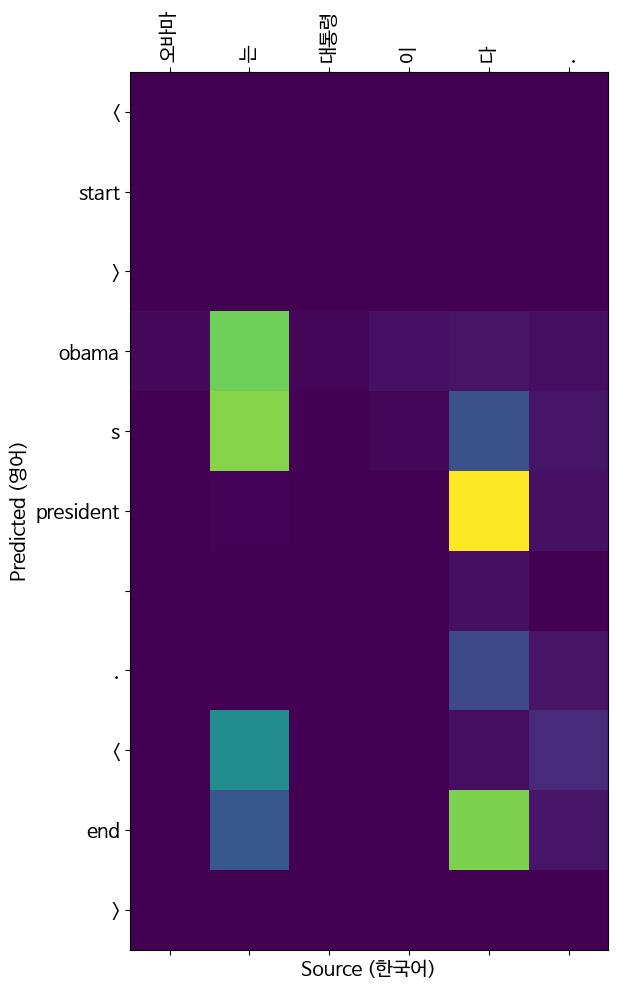

E1) < start > obama s president  . < end > <end>

Input: 시민들은 도시 속에 산다.
Preprocessed: 시민 들 은 도시 속 에 산다 .
Predicted: < start > citizens  , includ ing city  , the city s emergenc y cit ies < end >


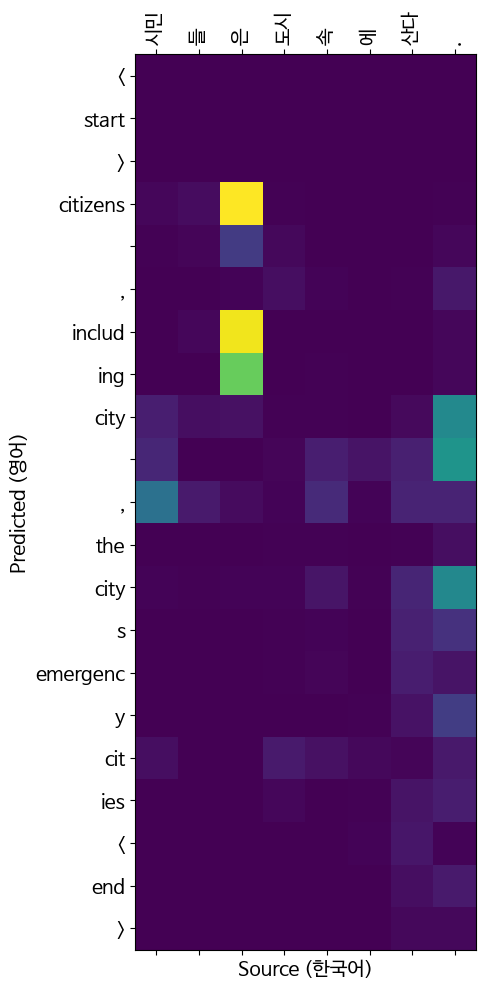

E2) < start > citizens  , includ ing city  , the city s emergenc y cit ies < end > <end>

Input: 커피는 필요 없다.
Preprocessed: 커피 는 필요 없 다 .
Predicted: < start > need s to implement the need for people need ed  . < end >


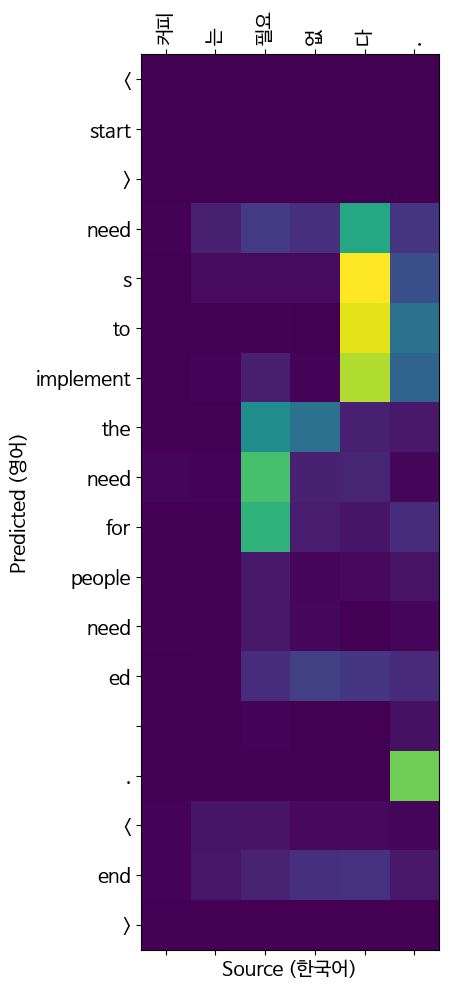

E3) < start > need s to implement the need for people need ed  . < end > <end>

Input: 일곱 명의 사망자가 발생했다.
Preprocessed: 일곱 명 의 사망자 가 발생 했 다 .
Predicted: < start > on thursday  , two people were kill ed  . < end >


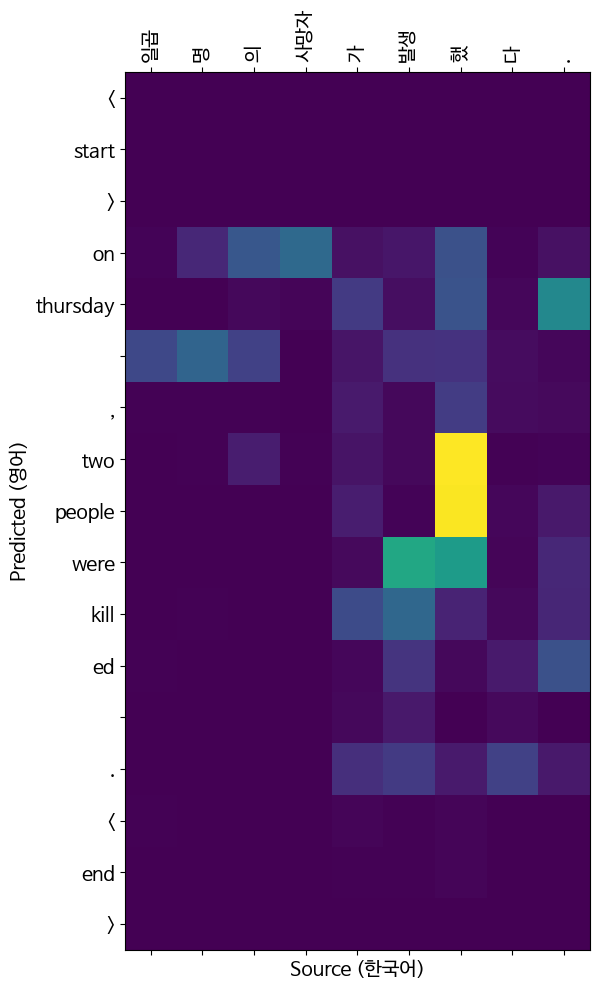

E4) < start > on thursday  , two people were kill ed  . < end > <end>



In [ ]:
print("=" * 60)
print("## 예문 번역 결과 ##")
print("=" * 60)

test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

print("\n## 제출 ##")
for i, sent in enumerate(test_sentences, 1):
    result = translate(sent, model, encoder_tokenizer, decoder_tokenizer, max_len=40)
    result_str = " ".join(result) + " <end>"
    print(f"E{i}) {result_str}\n")
